# Финальный проект — вариант 1

В проекте решены три задачи:

1. рассчитан retention по регистрационным когортам;
2. проанализирован A/B-тест акционных предложений;
3. предложены метрики тематического события.

Для статистических тестов используются готовые функции из **Pingouin** и **SciPy**.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pingouin as pg
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', '{:.4f}'.format)

## Загрузка данных

Для локального запуска все три исходных файла берутся напрямую из вашей папки `Downloads`.

In [2]:
# Ваши файлы задания 1
REG_PATH = Path('/Users/yaroslavzinchenko/Downloads/problem1-reg_data.csv')
AUTH_PATH = Path('/Users/yaroslavzinchenko/Downloads/problem1-auth_data.csv')

# Ваш файл задания 2
AB_PATH = Path('/Users/yaroslavzinchenko/Downloads/Проект_1_Задание_2.csv')

reg = pd.read_csv(REG_PATH, sep=';')
auth = pd.read_csv(AUTH_PATH, sep=';')
ab = pd.read_csv(AB_PATH, sep=';')

print('Регистрации:', reg.shape)
print('Авторизации:', auth.shape)
print('A/B-тест:', ab.shape)

Регистрации: (1000000, 2)
Авторизации: (9601013, 2)
A/B-тест: (404770, 3)


# Задание 1. Расчёт retention

Retention дня N — доля игроков регистрационной когорты, которые зашли в игру ровно через N дней после регистрации.

In [3]:
# Создаём копии, чтобы не менять исходные таблицы
reg_retention = reg.copy()
auth_retention = auth.copy()

# Переводим Unix-время в дату
reg_retention['reg_date'] = pd.to_datetime(reg_retention['reg_ts'], unit='s').dt.normalize()
auth_retention['auth_date'] = pd.to_datetime(auth_retention['auth_ts'], unit='s').dt.normalize()

# Берём полностью наблюдаемые когорты с 1 по 9 сентября
reg_retention = reg_retention[
    reg_retention['reg_date'].between('2020-09-01', '2020-09-09')
]

# Объединяем входы с датами регистрации
data = auth_retention.merge(reg_retention[['uid', 'reg_date']], on='uid')
data['day'] = (data['auth_date'] - data['reg_date']).dt.days
data = data[data['day'].between(0, 14)]

# Считаем размер каждой когорты и активных игроков по дням
cohort_size = reg_retention.groupby('reg_date')['uid'].nunique()
active_users = data.pivot_table(
    index='reg_date', columns='day', values='uid', aggfunc='nunique', fill_value=0
)

# Делим активных игроков на размер когорты
retention = active_users.div(cohort_size, axis=0) * 100
retention.round(2)

day,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
reg_date,,,,,,,,,,,,,,,
2020-09-01,100.0000,2.0200,4.1000,4.2200,4.6000,6.4300,5.6100,6.4300,4.1000,5.4200,5.1100,5.3600,4.8500,5.4900,4.2900
2020-09-02,100.0000,2.5200,3.9000,4.6600,5.6700,6.2300,7.1200,6.3000,4.8500,4.0900,5.6700,5.4800,5.4800,4.3500,4.9700
2020-09-03,100.0000,2.3300,5.4100,4.7100,6.5400,6.9800,8.5500,6.3500,5.4700,6.2900,6.3500,5.5300,5.8500,5.9700,5.4700
2020-09-04,100.0000,2.0100,3.6400,3.6400,5.1500,6.4000,7.2800,4.9600,5.3400,4.3300,5.6500,5.5200,4.3300,5.5900,4.3900
2020-09-05,100.0000,2.7600,3.9500,4.6400,5.4500,5.8900,7.4600,4.8900,5.0800,5.4500,6.0200,5.2000,4.5700,5.3900,4.5100
2020-09-06,100.0000,3.1300,4.3200,5.4400,5.6300,5.8800,6.8200,6.0700,5.8200,5.5000,4.8800,4.7500,5.3800,5.1900,5.5000
2020-09-07,100.0000,2.9400,4.2500,5.3700,5.0600,6.3700,7.3100,5.2500,4.1200,5.6200,6.0000,5.6800,4.5600,5.0600,4.2500
2020-09-08,100.0000,1.7500,3.9300,3.9300,4.8600,7.6100,7.5400,6.6100,5.1700,5.1700,6.5500,5.3600,5.9200,5.1700,4.7400
2020-09-09,100.0000,1.7400,3.2400,4.6700,5.7200,6.6600,5.7200,5.9100,4.3600,5.0400,3.7300,5.0400,4.7900,4.8500,2.4300


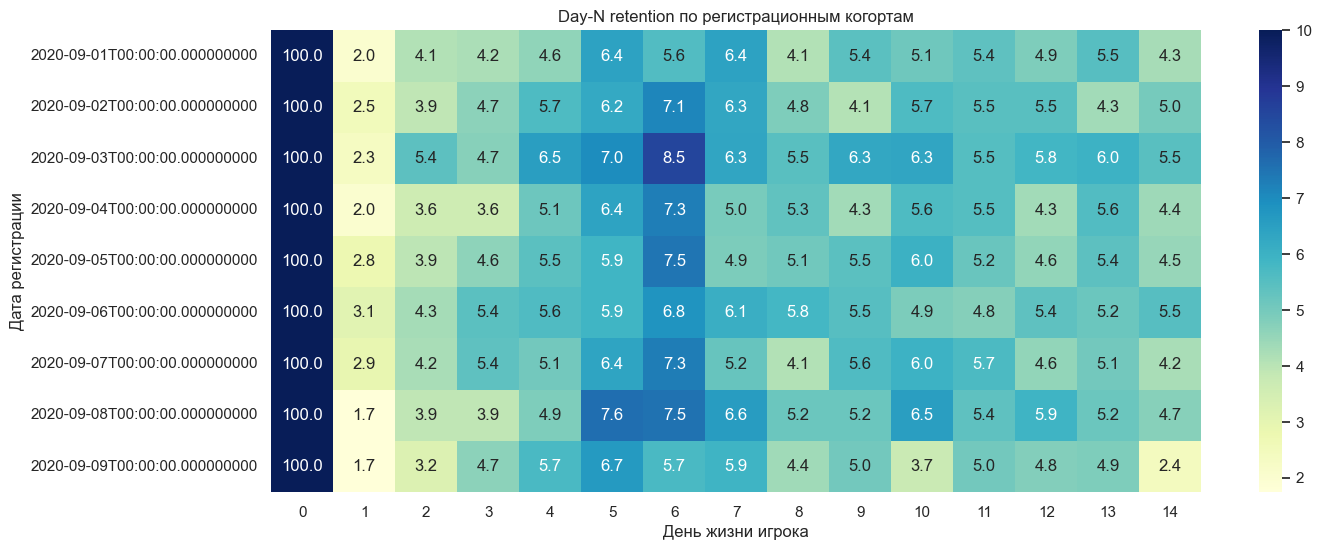

day
1    2.3500
7    5.8600
14   4.5000
dtype: float64

In [4]:
plt.figure(figsize=(15, 6))
sns.heatmap(retention, annot=True, fmt='.1f', cmap='YlGnBu', vmax=10)
plt.title('Day-N retention по регистрационным когортам')
plt.xlabel('День жизни игрока')
plt.ylabel('Дата регистрации')
plt.show()

# Взвешенный retention по ключевым дням
weighted_retention = retention.mul(cohort_size, axis=0).sum() / cohort_size.sum()
weighted_retention[[1, 7, 14]].round(2)

### Вывод по заданию 1

Для последних полностью наблюдаемых когорт получили:

- **D1 retention — 2,35%**;
- **D7 retention — 5,86%**;
- **D14 retention — 4,50%**.

Значения могут расти и снижаться, потому что это классический day-N retention, а не rolling retention.

# Задание 2. A/B-тест

Группа **A — контроль**, группа **B — тест**. Рассчитаем ARPU, конверсию в покупку и ARPPU.

In [5]:
ab['is_payer'] = ab['revenue'] > 0

metrics = ab.groupby('testgroup').agg(
    users=('user_id', 'nunique'),
    revenue=('revenue', 'sum'),
    arpu=('revenue', 'mean'),
    payers=('is_payer', 'sum')
)
metrics['conversion'] = metrics['payers'] / metrics['users'] * 100
metrics['arppu'] = metrics['revenue'] / metrics['payers']
metrics.round(3)

,users,revenue,arpu,payers,conversion,arppu
testgroup,,,,,,
a,202103,5136189,25.4140,1928,0.9540,2663.9980
b,202667,5421603,26.7510,1805,0.8910,3003.6580


## Статистические тесты

- ARPU и ARPPU сравниваем с помощью **Welch t-test** из `pingouin`;
- конверсию в покупку сравниваем с помощью **хи-квадрат** из `scipy.stats`;
- уровень значимости: 5%.

In [6]:
revenue_a = ab.loc[ab['testgroup'] == 'a', 'revenue']
revenue_b = ab.loc[ab['testgroup'] == 'b', 'revenue']
payers_a = revenue_a[revenue_a > 0]
payers_b = revenue_b[revenue_b > 0]

# ARPU
arpu_test = pg.ttest(revenue_a, revenue_b, correction=True)
print('ARPU:')
display(arpu_test[['T', 'dof', 'p_val', 'CI95']])

# ARPPU
arppu_test = pg.ttest(payers_a, payers_b, correction=True)
print('ARPPU:')
display(arppu_test[['T', 'dof', 'p_val', 'CI95']])

# Конверсия в покупку
conversion_table = pd.crosstab(ab['testgroup'], ab['is_payer'])
chi2, conversion_pvalue, dof, expected = stats.chi2_contingency(
    conversion_table, correction=False
)
print(f'Conversion: p-value = {conversion_pvalue:.4f}')

ARPU:


,T,dof,p_val,CI95
T_test,-0.6235,240991.1308,0.5330,"[-5.54, 2.87]"


ARPPU:


,T,dof,p_val,CI95
T_test,-1.6446,1943.4815,0.1002,"[-744.7, 65.38]"


Conversion: p-value = 0.0350


,count,mean,median,min,max
testgroup,,,,,
a,1928,2664.0000,311.0000,200,37433
b,1805,3003.6600,3022.0000,2000,4000


Крупных плательщиков в A: 123
Их доля в выручке A: 89.37%


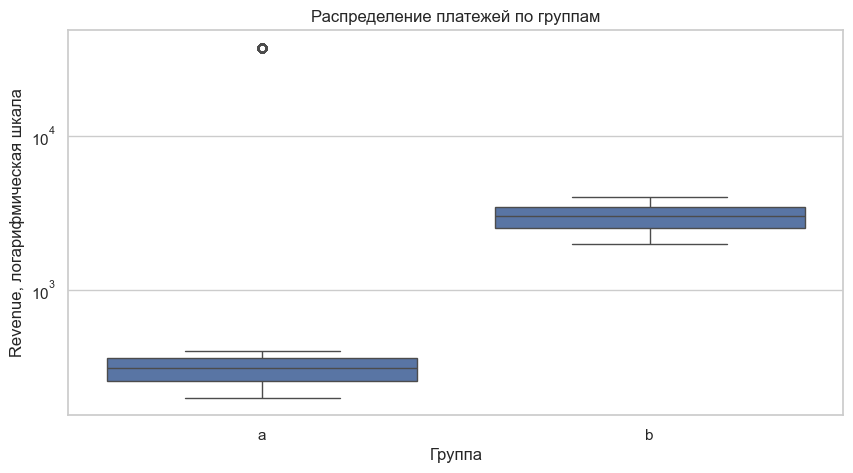

In [7]:
# Проверяем распределение платежей
payer_stats = (
    ab[ab['is_payer']]
      .groupby('testgroup')['revenue']
      .agg(['count', 'mean', 'median', 'min', 'max'])
)
display(payer_stats.round(2))

large_payers_a = payers_a[payers_a >= 35_000]
print('Крупных плательщиков в A:', len(large_payers_a))
print('Их доля в выручке A:', f'{large_payers_a.sum() / payers_a.sum():.2%}')

plt.figure(figsize=(10, 5))
sns.boxplot(data=ab[ab['is_payer']], x='testgroup', y='revenue')
plt.yscale('log')
plt.title('Распределение платежей по группам')
plt.xlabel('Группа')
plt.ylabel('Revenue, логарифмическая шкала')
plt.show()

## Вывод по A/B-тесту

| Метрика | A | B | p-value | Вывод |
|---|---:|---:|---:|---|
| ARPU | 25,41 | 26,75 | 0,533 | значимой разницы нет |
| Конверсия | 0,954% | 0,891% | 0,035 | в B значимо ниже |
| ARPPU | 2 664,00 | 3 003,66 | 0,100 | значимой разницы нет |

**Группу B пока нельзя признать лучшей.** Рост ARPU на 5% статистически не подтвердился, а конверсия в покупку значимо снизилась.

Дополнительно в A обнаружены 123 крупных плательщика, которые дают около 89% выручки группы. Удалять их после теста нельзя. Сначала нужно проверить корректность данных и баланс групп, затем провести повторный тест с разделением игроков по предыдущему платёжному поведению.

# Задание 3. Метрики тематического события

Для оценки события я бы использовал следующие группы метрик.

### Участие

- доля игроков, которые увидели событие;
- доля игроков, которые начали событие;
- участники события / DAU и MAU.

### Прохождение

- конверсия между уровнями;
- доля завершивших событие;
- доля получивших награду;
- среднее число попыток и время прохождения;
- уровни с максимальным оттоком игроков.

### Вовлечённость и удержание

- число игровых дней и сессий во время события;
- D1, D7 и D14 retention после начала события;
- churn после завершения события.

### Монетизация

- conversion to payer;
- ARPU и ARPPU;
- выручка от предложений события;
- расход внутриигровой валюты и бонусов.

Сравнивать участников с неучастниками напрямую недостаточно: активные игроки чаще сами начинают событие. Для оценки причинного эффекта лучше использовать A/B-тест или holdout-группу.

## Если после неудачи игрок откатывается назад

Основные метрики сохраняются, но нужно добавить:

- частоту и среднюю глубину отката;
- долю игроков, восстановивших потерянный прогресс;
- время восстановления;
- число повторных попыток;
- долю игроков, застрявших на одном участке;
- churn после отката;
- покупки бустеров после отката;
- обращения в поддержку и негативные отзывы.

Рост времени в игре сам по себе не будет успехом: он может быть вызван повторным прохождением и раздражением игроков. Поэтому его нужно рассматривать вместе с completion rate, retention и жалобами.

# Итог

1. Day-N retention рассчитан по регистрационным когортам.
2. Набор B пока не раскатываем: значимого роста ARPU нет, а конверсия снизилась.
3. Событие оцениваем через участие, прохождение, retention, монетизацию и негативные последствия.